<a href="https://colab.research.google.com/github/na2003-gif/E-business-index_projectbyNaphan/blob/main/EBI280225_MedE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip -q install geopandas matplotlib mapclassify
!pip -q install geodatasets
!pip -q install linearmodels
!pip -q install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.5 MB/s eta 0:00:00


# Data Cleaning

In [ ]:
import pandas as pd

file_path = '/content/280226.TC.xlsx'
df = pd.read_excel(file_path)

print(f"Successfully loaded data from {file_path}. Here are the first 5 rows:")
display(df.head())

Successfully loaded data from /content/280226.TC.xlsx. Here are the first 5 rows:


,Province-Year,Province,Year,PBR,EBI,POP,UR,GRDP,TC
0,An Giang 2018,An Giang,2018,5.992430,32.50,1931.0,2.51,40.4,7.570000
1,An Giang 2019,An Giang,2019,7.186188,35.80,1907.4,3.18,44.5,7.632807
2,An Giang 2020,An Giang,2020,7.297834,39.20,1904.5,2.53,46.6,8.650000
3,An Giang 2021,An Giang,2021,7.239880,5.44,1909.5,4.52,47.7,7.060000
4,An Giang 2022,An Giang,2022,7.538047,17.00,1905.5,3.32,52.4,7.520000


 **Clean data**

In [ ]:
import numpy as np

# Apply logarithmic transformation (log1p handles 0 values by adding 1 before log)
df['ln_PBR'] = np.log1p(df['PBR'])
df['ln_GRDP'] = np.log1p(df['GRDP'])
df['ln_POP'] = np.log1p(df['POP'])

print("DataFrame after applying logarithmic transformation to PBR, GRDP, and POP:")
display(df.head())

DataFrame after applying logarithmic transformation to PBR, GRDP, and POP:


,Province-Year,Province,Year,PBR,EBI,POP,UR,GRDP,TC,ln_PBR,ln_GRDP,ln_POP
0,An Giang 2018,An Giang,2018,5.992430,32.50,1931.0,2.51,40.4,7.570000,1.944828,3.723281,7.566311
1,An Giang 2019,An Giang,2019,7.186188,35.80,1907.4,3.18,44.5,7.632807,2.102448,3.817712,7.554020
2,An Giang 2020,An Giang,2020,7.297834,39.20,1904.5,2.53,46.6,8.650000,2.115995,3.862833,7.552500
3,An Giang 2021,An Giang,2021,7.239880,5.44,1909.5,4.52,47.7,7.060000,2.108986,3.885679,7.555120
4,An Giang 2022,An Giang,2022,7.538047,17.00,1905.5,3.32,52.4,7.520000,2.144532,3.977811,7.553024


In [ ]:
display(df[['ln_PBR', 'ln_GRDP', 'ln_POP', 'EBI', 'UR', 'TC']].describe().round(2))

,ln_PBR,ln_GRDP,ln_POP,EBI,UR,TC
count,255.00,255.00,255.00,255.00,255.00,255.00
mean,2.68,4.23,7.22,29.94,2.41,7.29
std,1.06,0.45,0.59,17.95,1.44,0.78
min,0.44,3.55,5.75,3.98,0.08,5.15
25%,1.95,3.90,6.82,14.00,1.45,6.78
50%,2.49,4.13,7.17,32.30,2.11,7.29
75%,3.17,4.45,7.49,39.60,3.17,7.88
max,6.17,5.88,9.15,90.60,9.41,9.50


# Data Descriptive

1. Descriptive EBI

In [ ]:
import geopandas as gpd

gdf = gpd.read_file("/content/diaphantinhenglish.geojson")
gdf = gdf.rename(columns={"Name": "Province"})
print(gdf.columns)
gdf.head()

Index(['Code', 'Province', 'geometry'], dtype='object')


,Code,Province,geometry
0,AD01,An Giang,"MULTIPOLYGON (((105.11524 10.95566, 105.11463 ..."
1,AD01,Ba Ria - Vung Tau,"MULTIPOLYGON (((106.0811 8.57754, 106.08069 8...."
2,AD01,Bac Giang,"MULTIPOLYGON (((106.16542 21.62022, 106.16925 ..."
3,AD01,Bac Kan,"MULTIPOLYGON (((105.7442 22.73519, 105.74624 2..."
4,AD01,Bac Lieu,"MULTIPOLYGON (((105.32591 9.60004, 105.32755 9..."


In [ ]:
import pandas as pd

file_path = '/content/EBI.xlsx'
df_EBI = pd.read_excel(file_path)

In [ ]:


import geodatasets
import geopandas as gpd

world_path = geodatasets.get_path("naturalearth.land")  # world land polygons
world = gpd.read_file(world_path)
asia = world.cx[95:125, 5:25]

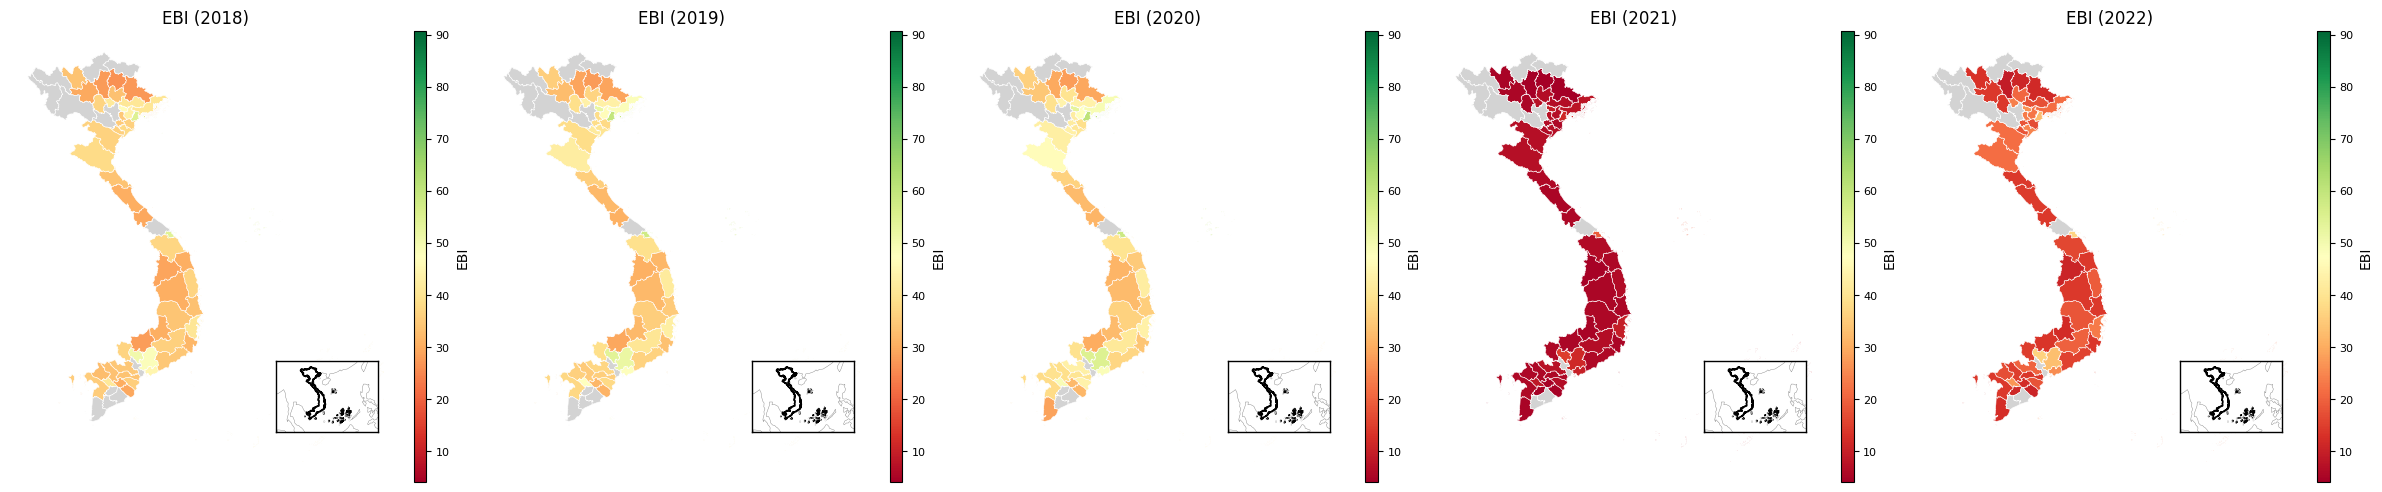

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from unidecode import unidecode
import geodatasets

# The following line is removed as 'Province' column already exists in df_EBI after loading.
# df_EBI = df_EBI.rename(columns={'Unnamed: 0': 'Province'})

# This line is removed as df_EBI is already in a long format with 'EBI' as a column, causing a ValueError.
# df_EBI = df_EBI.melt(id_vars=['Province'], var_name='Year', value_name='EBI')

# Data cleaning and preparation steps
df_EBI['Year'] = pd.to_numeric(df_EBI['Year'], errors='coerce')
df_EBI['EBI'] = df_EBI['EBI'].astype(str).str.replace(',', '.', regex=False)
df_EBI['EBI'] = pd.to_numeric(df_EBI['EBI'], errors='coerce')
df_EBI["Province"] = df_EBI["Province"].astype(str).str.strip()
df_EBI["prov_key"] = df_EBI["Province"].apply(lambda x: unidecode(x).lower().replace("-", " ").strip())

# Define `years` for plotting. Assuming we want to plot the last 5 available years.
# Based on other dataframes in the kernel, years from 2018 to 2022 are present.
years = [2018, 2019, 2020, 2021, 2022]

world = gpd.read_file(geodatasets.get_path("naturalearth.land")).to_crs("EPSG:4326")
vn_poly = gdf.to_crs("EPSG:4326").dissolve()
df_5y = df_EBI[df_EBI["Year"].isin(years)].copy()
vmin, vmax = df_5y["EBI"].min(), df_5y["EBI"].max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = mpl.colormaps["RdYlGn"]
inset_extent = (95, 5, 125, 25)
fig, axes = plt.subplots(1, 5, figsize=(24, 6))
axes = axes.flatten()

for ax, y in zip(axes, years):
    d_y = df_5y[df_5y["Year"] == y][["prov_key", "EBI"]]
    m = gdf.merge(d_y, on="prov_key", how="left")

    # Main map
    m.plot(
        column="EBI", ax=ax, cmap=cmap, norm=norm,
        linewidth=0.4, edgecolor="white",
        missing_kwds={"color": "lightgrey"},
        legend=False
    )
    ax.set_title(f"EBI ({y})", fontsize=12)
    ax.axis("off")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3%", pad=0.05)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cb = plt.colorbar(sm, cax=cax)
    cb.set_label("EBI", rotation=90)
    cb.ax.tick_params(labelsize=8)

    # Inset: VN
    iax = ax.inset_axes([0.68, 0.06, 0.26, 0.26])  # [x0,y0,w,h]
    world.boundary.plot(ax=iax, linewidth=0.3, color="grey")
    vn_poly.boundary.plot(ax=iax, linewidth=1.2, color="black")
    iax.set_xlim(inset_extent[0], inset_extent[2])
    iax.set_ylim(inset_extent[1], inset_extent[3])
    iax.set_xticks([]); iax.set_yticks([])
    for spine in iax.spines.values():
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.show()

2. Descriptive trends

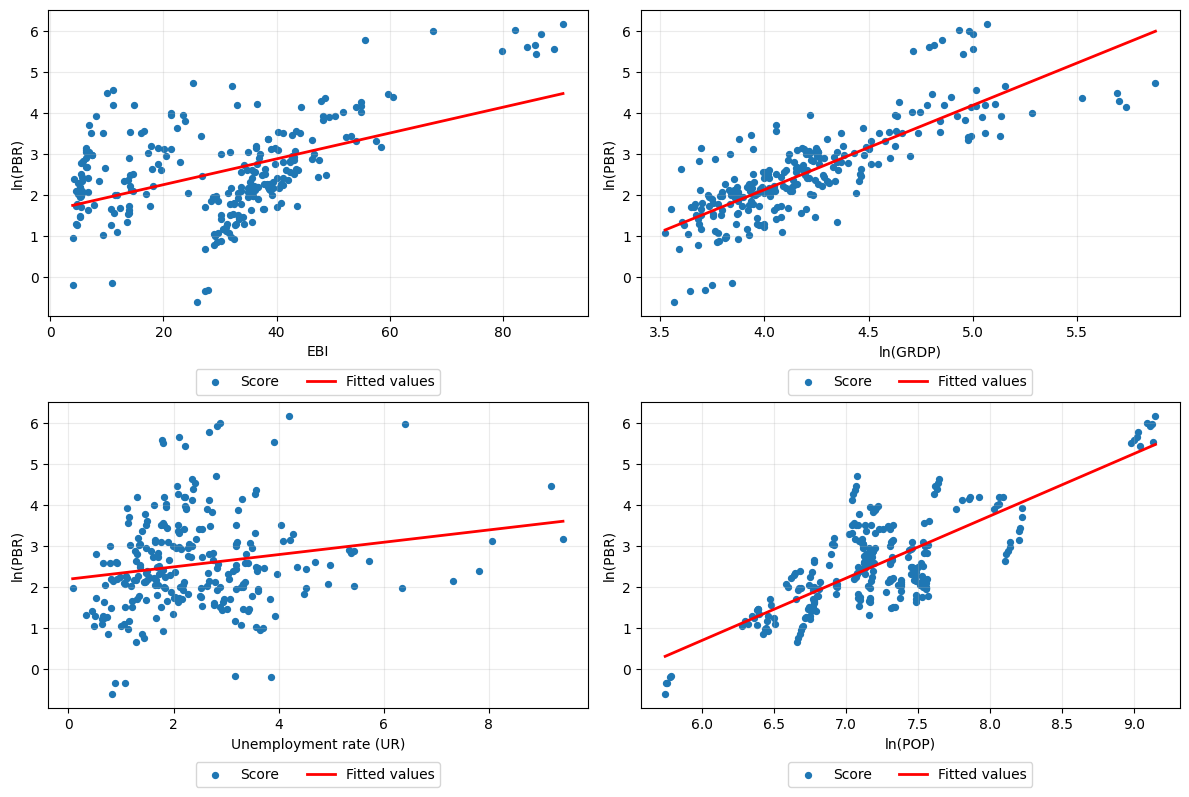

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

d = df.copy()
d["ln_PBR"]  = np.log(d["PBR"])
d["ln_GRDP"] = np.log(d["GRDP"])
d["ln_POP"]  = np.log(d["POP"])

def scatter_with_fit(ax, x, y, xlabel):
    # chấm
    ax.scatter(x, y, s=18, label="Score")
    # fitted line (linear)
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(np.nanmin(x), np.nanmax(x), 200)
    ax.plot(xs, m*xs + b, linewidth=2,color="red", label="Fitted values")

    ax.set_xlabel(xlabel)
    ax.set_ylabel("ln(PBR)")
    ax.grid(True, alpha=0.25)

    # legend dưới chart
    ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=2, frameon=True)

plots = [
    ("EBI",      "EBI"),
    ("ln_GRDP",  "ln(GRDP)"),
    ("UR",       "Unemployment rate (UR)"),
    ("ln_POP",   "ln(POP)"),
]

d_plot = d[["ln_PBR"] + [p[0] for p in plots]].dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (col, label) in zip(axes, plots):
    scatter_with_fit(ax, d_plot[col].values, d_plot["ln_PBR"].values, label)

plt.tight_layout()
plt.show()

# Benchmark Model

In [ ]:

import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS

# ---- 0) Prepare data ----
d = df.reset_index().copy()
# Trend terms
d["t"]  = d["Year"] - d["Year"].min()
d["t2"] = d["t"]**2

# Panel version (MultiIndex)
dp = d.set_index(["Province", "Year"]).sort_index()

y = dp["ln_PBR"]
X_base = sm.add_constant(dp[["EBI", "ln_GRDP", "ln_POP", "UR"]])

# ---- 1) Pooled OLS (HC1) ----
ols = sm.OLS(d["PBR"], sm.add_constant(d[["EBI","ln_GRDP","ln_POP","UR"]])).fit(cov_type="HC1")
print("\n# (1) Pooled OLS (HC1)")
print(ols.summary())

# helper to run PanelOLS
def run_panel(name, entity_fe=False, time_fe=False, cluster_entity=True, X=None):
    if X is None:
        X = X_base
    res = PanelOLS(y, X, entity_effects=entity_fe, time_effects=time_fe)\
        .fit(cov_type="clustered", cluster_entity=cluster_entity)
    print(f"\n# {name}")
    print(res.summary)
    return res
# ---- 2) Year FE only (no Province FE) ----
# PanelOLS có time_effects=True, entity_effects=False
run_panel("(2) Year FE only", entity_fe=False, time_fe=True, cluster_entity=True)
# ---- 3) Province FE + Year Trend (t, t2) (no Year FE) ----
X_trend = sm.add_constant(dp[["EBI","ln_GRDP","ln_POP","UR","t","t2"]])
run_panel("(5) Province FE + Year trend (t, t2)", entity_fe=False, time_fe=False, cluster_entity=True, X=X_trend)


# (1) Pooled OLS (HC1)
                            OLS Regression Results                            
Dep. Variable:                    PBR   R-squared:                       0.630
Model:                            OLS   Adj. R-squared:                  0.624
Method:                 Least Squares   F-statistic:                     27.01
Date:                Fri, 06 Mar 2026   Prob (F-statistic):           1.22e-18
Time:                        08:03:14   Log-Likelihood:                -1299.7
No. Observations:                 255   AIC:                             2609.
Df Residuals:                     250   BIC:                             2627.
Df Model:                           4                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -531.8129     67

Dep. Variable:,ln_PBR,R-squared:,0.9220
Estimator:,PanelOLS,R-squared (Between):,0.9370
No. Observations:,255,R-squared (Within):,0.4318
Date:,"Fri, Mar 06 2026",R-squared (Overall):,0.9220
Time:,08:03:14,Log-likelihood,-50.233
Cov. Estimator:,Clustered,,
,,F-statistic:,488.33
Entities:,51,P-value,0.0000
Avg Obs:,5.0000,Distribution:,"F(6,248)"
Min Obs:,5.0000,,
Max Obs:,5.0000,F-statistic (robust):,283.54


# Mediating Model

**1.  EBI_t → TC_t → PBR_t**

In [ ]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# Ensure df has a MultiIndex for PanelOLS
df_panel = df.set_index(['Province', 'Year']).sort_index()

y_m = df_panel["TC"]
X_m = df_panel[["EBI", "ln_GRDP", "ln_POP", "UR"]]
X_m = sm.add_constant(X_m)

res_m1 = PanelOLS(y_m, X_m, entity_effects=False, time_effects=True)\
        .fit(cov_type="clustered", cluster_entity=False)

print(res_m1.summary)

y = df_panel["ln_PBR"]

X = df_panel[["EBI", "TC", "ln_GRDP", "ln_POP", "UR"]]
X = sm.add_constant(X)

model_y = PanelOLS(
    y,
    X,
    entity_effects=False,
    time_effects=True
)

res_m2 = model_y.fit(
    cov_type="clustered",
    cluster_entity=False
)

print(res_m2.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                     TC   R-squared:                        0.0912
Estimator:                   PanelOLS   R-squared (Between):              0.1845
No. Observations:                 255   R-squared (Within):               0.0406
Date:                Fri, Mar 06 2026   R-squared (Overall):              0.1022
Time:                        08:13:43   Log-likelihood                   -262.46
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.1713
Entities:                          51   P-value                           0.0001
Avg Obs:                       5.0000   Distribution:                   F(4,246)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             7.8781
                            

**2.  EBI_{t-1} → TC_t → PBR_t**

In [ ]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

df_panel = df.set_index(["Province", "Year"]).sort_index().copy()

df_panel["EBI_l1"] = df_panel.groupby(level=0)["EBI"].shift(1)

# Model 1: EBI_{t-1} -> TC_t
data_m1 = df_panel[["TC", "EBI_l1", "ln_GRDP", "ln_POP", "UR"]].dropna()

y_m = data_m1["TC"]
X_m = data_m1[["EBI_l1", "ln_GRDP", "ln_POP", "UR"]]
X_m = sm.add_constant(X_m)

model_m1 = PanelOLS(
    y_m,
    X_m,
    entity_effects=False,
    time_effects=True
)

res_m1 = model_m1.fit(
    cov_type="clustered",
    cluster_entity=False
)

print("=== Model 1: EBI_{t-1} -> TC_t ===")
print(res_m1.summary)


# Model 2: EBI_{t-1} + TC_t -> PBR_t
data_m2 = df_panel[["ln_PBR", "EBI_l1", "TC", "ln_GRDP", "ln_POP", "UR"]].dropna()

y = data_m2["ln_PBR"]
X = data_m2[["EBI_l1", "TC", "ln_GRDP", "ln_POP", "UR"]]
X = sm.add_constant(X)

model_m2 = PanelOLS(
    y,
    X,
    entity_effects=False,
    time_effects=True
)

res_m2 = model_m2.fit(
    cov_type="clustered",
    cluster_entity=False
)

print("=== Model 2: EBI_{t-1} + TC_t -> ln(PBR)_t ===")
print(res_m2.summary)

=== Model 1: EBI_{t-1} -> TC_t ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                     TC   R-squared:                        0.1078
Estimator:                   PanelOLS   R-squared (Between):              0.2164
No. Observations:                 204   R-squared (Within):              -0.0139
Date:                Fri, Mar 06 2026   R-squared (Overall):              0.0857
Time:                        08:14:52   Log-likelihood                   -206.83
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.9216
Entities:                          51   P-value                           0.0002
Avg Obs:                       4.0000   Distribution:                   F(4,196)
Min Obs:                       4.0000                                           
Max Obs:                       4.0000   F-statistic (robust):             

**3. EBI_{t} → TC_t → PBR_{t+1}**

In [ ]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

df_panel = df.set_index(["Province", "Year"]).sort_index().copy()

df_panel["ln_PBR_f1"] = df_panel.groupby(level=0)["ln_PBR"].shift(-1)

# Model 1: EBI_t -> TC_t
data_m1 = df_panel[["TC", "EBI", "ln_GRDP", "ln_POP", "UR"]].dropna()

y_m = data_m1["TC"]
X_m = data_m1[["EBI", "ln_GRDP", "ln_POP", "UR"]]
X_m = sm.add_constant(X_m)

model_m1 = PanelOLS(
    y_m,
    X_m,
    entity_effects=False,
    time_effects=True
)

res_m1 = model_m1.fit(
    cov_type="clustered",
    cluster_entity=False
)

print("=== Model 1: EBI_t -> TC_t ===")
print(res_m1.summary)


# Model 2: EBI_t + TC_t -> ln(PBR)_{t+1}
data_m2 = df_panel[["ln_PBR_f1", "EBI", "TC", "ln_GRDP", "ln_POP", "UR"]].dropna()

y = data_m2["ln_PBR_f1"]
X = data_m2[["EBI", "TC", "ln_GRDP", "ln_POP", "UR"]]
X = sm.add_constant(X)

model_m2 = PanelOLS(
    y,
    X,
    entity_effects=False,
    time_effects=True
)

res_m2 = model_m2.fit(
    cov_type="clustered",
    cluster_entity=False
)

print("=== Model 2: EBI_t + TC_t -> ln(PBR)_(t+1) ===")
print(res_m2.summary)


# Baseline: EBI_t -> ln(PBR)_{t+1}
data_base = df_panel[["ln_PBR_f1", "EBI", "ln_GRDP", "ln_POP", "UR"]].dropna()

y_base = data_base["ln_PBR_f1"]
X_base = data_base[["EBI", "ln_GRDP", "ln_POP", "UR"]]
X_base = sm.add_constant(X_base)

model_base = PanelOLS(
    y_base,
    X_base,
    entity_effects=False,
    time_effects=True
)

res_base = model_base.fit(
    cov_type="clustered",
    cluster_entity=False
)

print("=== Baseline: EBI_t -> ln(PBR)_(t+1) ===")
print(res_base.summary)

=== Model 1: EBI_t -> TC_t ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                     TC   R-squared:                        0.0912
Estimator:                   PanelOLS   R-squared (Between):              0.1845
No. Observations:                 255   R-squared (Within):               0.0406
Date:                Fri, Mar 06 2026   R-squared (Overall):              0.1022
Time:                        08:15:51   Log-likelihood                   -262.46
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      6.1713
Entities:                          51   P-value                           0.0001
Avg Obs:                       5.0000   Distribution:                   F(4,246)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             7.87

**4. MedE Model for UAC (RANDOM VAR IN TC): EBI_t → UAC_t-> EBI_t**

In [ ]:
file_path = '/content/EBI.10326.UAC.xlsx'
df3 = pd.read_excel(file_path)

print(f"Successfully loaded data from {file_path}. Here are the first 5 rows:")
display(df3.head())

Successfully loaded data from /content/EBI.10326.UAC.xlsx. Here are the first 5 rows:


,Province-Year,Province,Year,PBR,EBI,POP,UR,GRDP,TC,UAC
0,An Giang 2018,An Giang,2018,5.992430,32.50,1931.0,2.51,40.4,7.570000,0.28
1,An Giang 2019,An Giang,2019,7.186188,35.80,1907.4,3.18,44.5,7.632807,0.26
2,An Giang 2020,An Giang,2020,7.297834,39.20,1904.5,2.53,46.6,8.650000,0.19
3,An Giang 2021,An Giang,2021,7.239880,5.44,1909.5,4.52,47.7,7.060000,0.19
4,An Giang 2022,An Giang,2022,7.538047,17.00,1905.5,3.32,52.4,7.520000,0.26


In [ ]:
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import numpy as np

file_path = "/content/EBI.10326.UAC.xlsx"
df3 = pd.read_excel(file_path)

df3.columns = df3.columns.str.strip()
df3 = df3.set_index(["Province", "Year"]).sort_index()

# Apply logarithmic transformations to df3 for consistency
df3['ln_PBR'] = np.log1p(df3['PBR'])
df3['ln_GRDP'] = np.log1p(df3['GRDP'])
df3['ln_POP'] = np.log1p(df3['POP'])

data_m1 = df3[["UAC", "EBI", "ln_GRDP", "ln_POP", "UR"]].dropna()

y_m = data_m1["UAC"]
X_m = data_m1[["EBI", "ln_GRDP", "ln_POP", "UR"]]
X_m = sm.add_constant(X_m)

model_m1 = PanelOLS(
    y_m,
    X_m,
    entity_effects=True,
    time_effects=True
)

res_m1 = model_m1.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== Model 1: EBI_t -> UAC_t ===")
print(res_m1.summary)
data_m2 = df3[["ln_PBR", "EBI", "UAC", "ln_GRDP", "ln_POP", "UR"]].dropna()

y = data_m2["ln_PBR"]
X = data_m2[["EBI", "UAC", "ln_GRDP", "ln_POP", "UR"]]
X = sm.add_constant(X)

model_m2 = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

res_m2 = model_m2.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== Model 2: EBI_t + UAC_t -> ln(PBR)_t ===")
print(res_m2.summary)

=== Model 1: EBI_t -> UAC_t ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                    UAC   R-squared:                        0.0116
Estimator:                   PanelOLS   R-squared (Between):             -51.417
No. Observations:                 255   R-squared (Within):               0.0534
Date:                Fri, Mar 06 2026   R-squared (Overall):             -8.9107
Time:                        08:22:21   Log-likelihood                    402.27
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      0.5743
Entities:                          51   P-value                           0.6816
Avg Obs:                       5.0000   Distribution:                   F(4,196)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             0.3

In [35]:
import pandas as pd

file_path = '/content/Ebi.5y.medvar.TC.SUBxlsx.xlsx'
d4 = pd.read_excel(file_path)
import numpy as np
# Strip whitespace from column names
d4.columns = d4.columns.str.strip()
d4['ln_PBR'] = np.log1p(d4['PBR'])
d4['ln_GRDP'] = np.log1p(d4['GRDP'])
d4['ln_POP'] = np.log1p(d4['POP'])
display(d4.head())


,Province-Year,Province,Year,PBR,EBI,POP,UR,GRDP,TC,UAC,FL,FT,PW,TAP,ln_PBR,ln_GRDP,ln_POP
0,An Giang 2018,An Giang,2018,5.992430,32.50,1931.0,2.51,40.4,7.570000,0.28,0.89,0.56,0.61,0.76,1.944828,3.723281,7.566311
1,An Giang 2019,An Giang,2019,7.186188,35.80,1907.4,3.18,44.5,7.632807,0.26,0.95,0.67,0.60,0.79,2.102448,3.817712,7.554020
2,An Giang 2020,An Giang,2020,7.297834,39.20,1904.5,2.53,46.6,8.650000,0.19,0.95,0.72,0.71,0.82,2.115995,3.862833,7.552500
3,An Giang 2021,An Giang,2021,7.239880,5.44,1909.5,4.52,47.7,7.060000,0.19,0.97,0.81,0.79,0.83,2.108986,3.885679,7.555120
4,An Giang 2022,An Giang,2022,7.538047,17.00,1905.5,3.32,52.4,7.520000,0.26,0.93,0.80,0.74,0.79,2.144532,3.977811,7.553024


5. mediators = ["FL", "FT", "PW", "TAP"]

In [40]:
import pandas as pd
import statsmodels.api as sm
from linearmodels.panel import PanelOLS
import numpy as np

# Ensure d4 is properly indexed as PanelOLS requires a 2-level MultiIndex
# Reset any existing index to ensure 'Province' and 'Year' are columns before setting a new MultiIndex.
d4 = d4.reset_index()
d4 = d4.set_index(["Province", "Year"]).sort_index()
moderators = ["FL", "FT", "PW", "TAP"]

for m in moderators:

    print("\n==============================")
    print(f"MODERATOR = {m}")
    print("==============================")

    data_mod = d4[["ln_PBR", "EBI", m, "ln_GRDP", "ln_POP", "UR"]].dropna().copy()

    # Mean-centering
    data_mod["EBI_c"] = data_mod["EBI"] - data_mod["EBI"].mean()
    data_mod[f"{m}_c"] = data_mod[m] - data_mod[m].mean()

    # Interaction term
    data_mod[f"EBI_{m}"] = data_mod["EBI_c"] * data_mod[f"{m}_c"]

    y = data_mod["ln_PBR"]
    X = data_mod[["EBI_c", f"{m}_c", f"EBI_{m}", "ln_GRDP", "ln_POP", "UR"]]
    X = sm.add_constant(X)

    model_mod = PanelOLS(
        y,
        X,
        entity_effects=True,
        time_effects=True
    )

    res_mod = model_mod.fit(
        cov_type="clustered",
        cluster_entity=True
    )

    print(f"\n=== Moderation Model: EBI × {m} -> ln(PBR) ===")
    print(res_mod.summary)


MODERATOR = FL

=== Moderation Model: EBI × FL -> ln(PBR) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_PBR   R-squared:                        0.1506
Estimator:                   PanelOLS   R-squared (Between):              0.8545
No. Observations:                 245   R-squared (Within):               0.4672
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.8373
Time:                        06:24:21   Log-likelihood                    163.19
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.4971
Entities:                          49   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                   F(6,186)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-stat

6. Par
EBI_t ->PAR_t ->ln(PBR)_t


In [18]:
import pandas as pd

file_path = '/content/EBI.5y.medvar.Par.xlsx'
dpar = pd.read_excel(file_path)
import numpy as np
# Strip whitespace from column names
dpar.columns = dpar.columns.str.strip()
dpar['ln_PBR'] = np.log1p(dpar['PBR'])
dpar['ln_GRDP'] = np.log1p(dpar['GRDP'])
dpar['ln_POP'] = np.log1p(dpar['POP']) # Corrected line
display(dpar.head())


,Province-Year,Province,Year,PBR,EBI,POP,UR,GRDP,Par,ln_PBR,ln_GRDP,ln_POP
0,An Giang 2018,An Giang,2018,5.992430,32.50,1931.0,2.51,40.4,80.77,1.944828,3.723281,7.566311
1,An Giang 2019,An Giang,2019,7.186188,35.80,1907.4,3.18,44.5,83.32,2.102448,3.817712,7.554020
2,An Giang 2020,An Giang,2020,7.297834,39.20,1904.5,2.53,46.6,84.67,2.115995,3.862833,7.552500
3,An Giang 2021,An Giang,2021,7.239880,5.44,1909.5,4.52,47.7,85.22,2.108986,3.885679,7.555120
4,An Giang 2022,An Giang,2022,7.538047,17.00,1905.5,3.32,52.4,84.22,2.144532,3.977811,7.553024


In [25]:
# -----------------------------
# Model 0: Baseline
# EBI_t -> ln(PBR)_t
# -----------------------------

# Ensure dpar has a MultiIndex for PanelOLS
#dpar = dpar.set_index(["Province", "Year"]).sort_index()

data_base = dpar[["ln_PBR", "EBI", "ln_GRDP", "ln_POP", "UR"]].dropna()

y_base = data_base["ln_PBR"]
X_base = data_base[["EBI", "ln_GRDP", "ln_POP", "UR"]]
X_base = sm.add_constant(X_base)

model_base = PanelOLS(
    y_base,
    X_base,
    entity_effects=False,
    time_effects=True
)

res_base = model_base.fit(
    cov_type="clustered",
    cluster_entity=False
)

print("=== Model 0: EBI_t -> ln(PBR)_t ===")
print(res_base.summary)


# -----------------------------
# Model 1: Mediator model
# EBI_t -> Par_t
# -----------------------------
data_m1 = dpar[["Par", "EBI", "ln_GRDP", "ln_POP", "UR"]].dropna()

y_m = data_m1["Par"]
X_m = data_m1[["EBI", "ln_GRDP", "ln_POP", "UR"]]
X_m = sm.add_constant(X_m)

model_m1 = PanelOLS(
    y_m,
    X_m,
    entity_effects=False,
    time_effects=True
)

res_m1 = model_m1.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== Model 1: EBI_t -> Par_t ===")
print(res_m1.summary)


# -----------------------------
# Model 2: Mediation model
# EBI_t + Par_t -> ln(PBR)_t
# -----------------------------
data_m2 = dpar[["ln_PBR", "EBI", "Par", "ln_GRDP", "ln_POP", "UR"]].dropna()

y = data_m2["ln_PBR"]
X = data_m2[["EBI", "Par", "ln_GRDP", "ln_POP", "UR"]]
X = sm.add_constant(X)

model_m2 = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=False
)

res_m2 = model_m2.fit(
    cov_type="clustered",
    cluster_entity=False
)

print("=== Model 2: EBI_t + Par_t -> ln(PBR)_t ===")
print(res_m2.summary)


=== Model 0: EBI_t -> ln(PBR)_t ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_PBR   R-squared:                        0.9253
Estimator:                   PanelOLS   R-squared (Between):              0.9400
No. Observations:                 255   R-squared (Within):              -0.0186
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.9116
Time:                        06:05:53   Log-likelihood                   -43.053
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      761.59
Entities:                          51   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                   F(4,246)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):            

# Moderator Model

**1. ln(PBR) = EBI + TC +(EBI * TC)**

In [ ]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

df_panel = df.set_index(["Province", "Year"]).sort_index().copy()

df_panel["EBI_TC"] = df_panel["EBI"] * df_panel["TC"]

y = df_panel["ln_PBR"]

X = df_panel[["EBI", "TC", "EBI_TC", "ln_GRDP", "ln_POP", "UR"]]
X = sm.add_constant(X)

model_mod = PanelOLS(
    y,
    X,
    entity_effects=False,
    time_effects=True
)

res_mod = model_mod.fit(
    cov_type="clustered",
    cluster_entity=False
)

print(res_mod.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_PBR   R-squared:                        0.9258
Estimator:                   PanelOLS   R-squared (Between):              0.9408
No. Observations:                 255   R-squared (Within):              -0.0501
Date:                Fri, Mar 06 2026   R-squared (Overall):              0.9114
Time:                        08:24:09   Log-likelihood                   -42.080
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      507.77
Entities:                          51   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                   F(6,244)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             751.25
                            

In [27]:
d4 = d4.set_index(["Province", "Year"]).sort_index()

moderators = ["FL","FT","PW","TAP"]

for m in moderators:

    print("\n==============================")
    print(f"MODERATOR = {m}")
    print("==============================")

    data = d4[["ln_PBR","EBI",m,"ln_GRDP","ln_POP","UR"]].dropna().copy()

    # mean centering
    data["EBI_c"] = data["EBI"] - data["EBI"].mean()
    data[f"{m}_c"] = data[m] - data[m].mean()

    # interaction
    data[f"EBI_{m}"] = data["EBI_c"] * data[f"{m}_c"]

    y = data["ln_PBR"]

    X = data[["EBI_c",f"{m}_c",f"EBI_{m}","ln_GRDP","ln_POP","UR"]]
    X = sm.add_constant(X)

    model = PanelOLS(
        y,
        X,
        entity_effects=True,
        time_effects=True
    )

    res = model.fit(
        cov_type="clustered",
        cluster_entity=True
    )

    print(res.summary)


MODERATOR = FL


KeyError: "['FL'] not in index"

In [26]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from linearmodels.panel import PanelOLS

file_path = "/content/EBI.5y.medvar.Par.xlsx"
dpar = pd.read_excel(file_path)

dpar.columns = dpar.columns.str.strip()

dpar["ln_PBR"] = np.log1p(dpar["PBR"])
dpar["ln_GRDP"] = np.log1p(dpar["GRDP"])
dpar["ln_POP"] = np.log1p(dpar["POP"])

# Mean-center for moderation
dpar["EBI_c"] = dpar["EBI"] - dpar["EBI"].mean()
dpar["PAR_c"] = dpar["Par"] - dpar["Par"].mean()

# Interaction term
dpar["EBI_PAR"] = dpar["EBI_c"] * dpar["PAR_c"]

# Set panel index
dpar = dpar.set_index(["Province", "Year"]).sort_index()

# Keep needed variables
data_mod = dpar[["ln_PBR", "EBI_c", "PAR_c", "EBI_PAR", "ln_GRDP", "ln_POP", "UR"]].dropna()

y = data_mod["ln_PBR"]
X = data_mod[["EBI_c", "PAR_c", "EBI_PAR", "ln_GRDP", "ln_POP", "UR"]]
X = sm.add_constant(X)

model_mod = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

res_mod = model_mod.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== Moderation Model: EBI × PAR -> ln(PBR) ===")
print(res_mod.summary)

=== Moderation Model: EBI × PAR -> ln(PBR) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_PBR   R-squared:                        0.1426
Estimator:                   PanelOLS   R-squared (Between):              0.6512
No. Observations:                 254   R-squared (Within):               0.4959
Date:                Mon, Mar 09 2026   R-squared (Overall):              0.6462
Time:                        06:09:54   Log-likelihood                    165.51
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.3514
Entities:                          51   P-value                           0.0000
Avg Obs:                       4.9804   Distribution:                   F(6,193)
Min Obs:                       4.0000                                           
Max Obs:                       5.0000   F-statistic (robust): 

# Threshold Model

In [ ]:
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

df_panel = df.set_index(["Province", "Year"]).sort_index().copy()

tau_hat = 31.4

df_panel["EBI_low"] = df_panel["EBI"] * (df_panel["EBI"] <= tau_hat).astype(int)
df_panel["EBI_high"] = df_panel["EBI"] * (df_panel["EBI"] > tau_hat).astype(int)

data_thr_med = df_panel[["ln_PBR", "EBI_low", "EBI_high", "TC", "ln_GRDP", "ln_POP", "UR"]].dropna()

y = data_thr_med["ln_PBR"]
X = data_thr_med[["EBI_low", "EBI_high", "TC", "ln_GRDP", "ln_POP", "UR"]]
X = sm.add_constant(X)

model_thr_med = PanelOLS(
    y,
    X,
    entity_effects=True,
    time_effects=True
)

res_thr_med = model_thr_med.fit(
    cov_type="clustered",
    cluster_entity=True
)

print("=== Threshold + Mediator Model ===")
print(res_thr_med.summary)

=== Threshold + Mediator Model ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                 ln_PBR   R-squared:                        0.1557
Estimator:                   PanelOLS   R-squared (Between):              0.8651
No. Observations:                 255   R-squared (Within):               0.4475
Date:                Fri, Mar 06 2026   R-squared (Overall):              0.8527
Time:                        08:28:21   Log-likelihood                    166.19
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5.9618
Entities:                          51   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                   F(6,194)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             